# Netflix UK Content Demand Analysis

## Business question

Which shows should be shortlisted for further acquisition, licensing or recommissioning research?

I use IMDb ratings and votes to measure proven audience approval, Netflix weekly Top 10 data to measure viewing demand and momentum, and scenario analysis to show how an analyst could compare possible value and cost. Commercial fields that are not in the source data stay blank so that estimates are not presented as facts.

I chose this project because I wanted to practise pandas and Matplotlib around a decision rather than produce charts without a clear purpose. The main lesson from the analysis was that strong demand does not automatically mean a title is obtainable or profitable.

## 1. Import the tools and define the project folders

The comments explain why each line is needed in this project. I have kept the code straightforward so the analysis is easy to follow and reproduce.

In [1]:
# Path lets the notebook find the data folder on Windows, macOS or Linux.
from pathlib import Path

# NumPy is used for missing values and conditional labels.
import numpy as np

# Pandas loads, cleans, joins and summarizes the three datasets.
import pandas as pd

# Matplotlib creates the charts used in the final recommendation.
import matplotlib.pyplot as plt

# This formatter makes large viewer numbers easier to read on chart axes.
import matplotlib.ticker as mtick

# The project files are stored relative to this notebook so another person can run it.
DATA_FOLDER = Path("data")

# Finished tables are saved here instead of mixing them with the raw data.
OUTPUT_FOLDER = Path("outputs")

# Finished charts are saved separately so they can be displayed in the README.
IMAGE_FOLDER = Path("images")

# These folders are created if they do not already exist.
OUTPUT_FOLDER.mkdir(exist_ok=True)
IMAGE_FOLDER.mkdir(exist_ok=True)

# Wider table output makes the decision columns easier to inspect in the notebook.
pd.set_option("display.max_columns", 50)

# This colour set gives every chart a consistent appearance.
colours = {"navy": "#16324F", "blue": "#247BA0", "green": "#4D9078", "gold": "#F2C14E", "red": "#D1495B", "grey": "#6C757D"}

# These settings remove the default Matplotlib appearance and keep the charts consistent.
plt.rcParams.update({"figure.figsize": (11, 6), "figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.2})

## 2. Import the data with pandas

Only the columns used in the analysis are imported. Dates are parsed while loading, and text identifiers are given explicit string types.

In [2]:
# These are the weekly viewing columns needed for demand, momentum and reliability.
weekly_columns = ["week", "category", "weekly_rank", "show_title", "season_title", "weekly_hours_viewed", "weekly_views"]

# parse_dates converts the week column immediately instead of leaving it as text.
weekly = pd.read_csv(DATA_FOLDER / "netflix_weekly_top10.csv", usecols=weekly_columns, parse_dates=["week"], dtype={"category": "string", "show_title": "string", "season_title": "string"})

# These IMDb columns provide the title, rating, vote count and supporting metadata.
imdb_columns = ["title", "year", "certificate", "duration", "genre", "rating", "votes"]

# The title fields are kept as strings because they will be cleaned before the join.
imdb = pd.read_csv(DATA_FOLDER / "imdb_ratings.csv", usecols=imdb_columns, dtype={"title": "string", "year": "string", "certificate": "string", "duration": "string", "genre": "string", "votes": "string"})

# These catalogue columns help identify titles that have appeared in Netflix's catalogue.
catalogue_columns = ["show_id", "type", "title", "country", "date_added", "release_year", "rating", "duration", "listed_in"]

# date_added is parsed as a date because it is a timing field rather than ordinary text.
catalogue = pd.read_csv(DATA_FOLDER / "netflix_titles.csv", usecols=catalogue_columns, parse_dates=["date_added"], dtype={"show_id": "string", "type": "string", "title": "string", "country": "string"})

# The shapes confirm that all three files loaded and show the amount of data available.
print("Weekly Top 10:", weekly.shape)
print("IMDb ratings:", imdb.shape)
print("Netflix catalogue:", catalogue.shape)

Weekly Top 10: (5380, 7)
IMDb ratings: (9957, 7)
Netflix catalogue: (2410, 9)


## 3. Inspect the data before cleaning

I check structure, summary statistics, missing values and duplicate rows before making cleaning decisions.

In [3]:
# A dictionary makes it possible to run the same checks on each dataframe without repeating code.
datasets = {"Weekly Top 10": weekly, "IMDb ratings": imdb, "Netflix catalogue": catalogue}

# This loop gives every dataset the same first-pass quality check.
for name, dataframe in datasets.items():
    # The heading makes the printed results easy to separate.
    print(f"\n--- {name} ---")
    # info shows the column names, data types and non-null counts.
    dataframe.info()
    # describe summarizes both numeric and text columns.
    display(dataframe.describe(include="all").T)
    # isnull counts missing values so they can be handled deliberately.
    display(dataframe.isnull().sum().to_frame("missing_values"))
    # duplicated checks whether identical records could inflate the results.
    print("Duplicate rows:", dataframe.duplicated().sum())


--- Weekly Top 10 ---
<class 'pandas.DataFrame'>
RangeIndex: 5380 entries, 0 to 5379
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   week                 5380 non-null   datetime64[us]
 1   category             5380 non-null   string        
 2   weekly_rank          5380 non-null   int64         
 3   show_title           5380 non-null   string        
 4   season_title         5209 non-null   string        
 5   weekly_hours_viewed  5380 non-null   int64         
 6   weekly_views         3340 non-null   float64       
dtypes: datetime64[us](1), float64(1), int64(2), string(3)
memory usage: 294.3 KB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
week,5380,NaN,NaN,NaN,2024-01-28 00:00:00,2021-07-04 00:00:00,2022-10-16 00:00:00,2024-01-28 00:00:00,2025-05-11 00:00:00,2026-08-23 00:00:00,NaN
category,5380,2,TV (English),2690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekly_rank,5380.0,NaN,NaN,NaN,5.5,1.0,3.0,5.5,8.0,10.0,2.872548
show_title,5380,1251,Stranger Things,101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
season_title,5209,1631,Squid Game: Season 1,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekly_hours_viewed,5380.0,NaN,NaN,NaN,24943892.193309,800000.0,9920000.0,15955000.0,28112500.0,571760000.0,31886497.599879
weekly_views,3340.0,NaN,NaN,NaN,3962275.449102,700000.0,1800000.0,2700000.0,4300000.0,68000000.0,4498482.214057


,missing_values
week,0
category,0
weekly_rank,0
show_title,0
season_title,171
weekly_hours_viewed,0
weekly_views,2040


Duplicate rows: 0

--- IMDb ratings ---
<class 'pandas.DataFrame'>
RangeIndex: 9957 entries, 0 to 9956
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9957 non-null   string 
 1   year         9430 non-null   string 
 2   certificate  6504 non-null   string 
 3   duration     7921 non-null   string 
 4   genre        9884 non-null   string 
 5   rating       8784 non-null   float64
 6   votes        8784 non-null   string 
dtypes: float64(1), string(6)
memory usage: 544.7 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
title,9957,7912,Top Gear,92,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,9430,498,(2020),663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
certificate,6504,20,TV-MA,2520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,7921,291,60 min,385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,9884,569,Comedy,859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,8784.0,NaN,NaN,NaN,6.764515,1.21484,1.7,6.1,6.9,7.6,9.9
votes,8784,4862,30,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_values
title,0
year,527
certificate,3453
duration,2036
genre,73
rating,1173
votes,1173


Duplicate rows: 111

--- Netflix catalogue ---
<class 'pandas.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       2410 non-null   string        
 1   type          2410 non-null   string        
 2   title         2410 non-null   string        
 3   country       2133 non-null   string        
 4   date_added    2400 non-null   datetime64[us]
 5   release_year  2410 non-null   int64         
 6   rating        2408 non-null   str           
 7   duration      2410 non-null   str           
 8   listed_in     2410 non-null   str           
dtypes: datetime64[us](1), int64(1), str(3), string(4)
memory usage: 169.6 KB


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
show_id,2410,2410,s1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,2410,1,TV Show,2410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,2410,2409,????,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,2133,183,United States,705,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,2400,NaN,NaN,NaN,2019-01-19 15:45:36,2008-02-04 00:00:00,2018-01-17 00:00:00,2019-04-24 00:00:00,2020-03-13 00:00:00,2021-01-15 00:00:00,NaN
release_year,2410.0,NaN,NaN,NaN,2016.191701,1925.0,2015.0,2018.0,2019.0,2021.0,5.664826
rating,2408,9,TV-MA,1018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,2410,15,1 Season,1608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,2410,227,Kids' TV,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_values
show_id,0
type,0
title,0
country,277
date_added,10
release_year,0
rating,2
duration,0
listed_in,0


Duplicate rows: 0


## 4. Clean titles and numeric fields

Rows without a usable title or week cannot be matched or placed in time, so only those essential missing records are removed. Other missing values remain missing rather than being replaced with zero.

In [4]:
# Rows without a show title or week cannot contribute to a title-level time analysis.
weekly = weekly.dropna(subset=["show_title", "week"]).drop_duplicates().copy()

# IMDb rows without a title cannot be joined to the viewing data.
imdb = imdb.dropna(subset=["title"]).drop_duplicates().copy()

# Catalogue rows without a title cannot be used to check historical catalogue presence.
catalogue = catalogue.dropna(subset=["title"]).drop_duplicates().copy()

# Errors become missing values because invalid viewing numbers should not be treated as real zeros.
weekly["weekly_views"] = pd.to_numeric(weekly["weekly_views"], errors="coerce")

# The same deliberate conversion is applied to viewing hours.
weekly["weekly_hours_viewed"] = pd.to_numeric(weekly["weekly_hours_viewed"], errors="coerce")

# IMDb ratings should be numeric so they can be compared and scored.
imdb["rating"] = pd.to_numeric(imdb["rating"], errors="coerce")

# Commas are removed from vote counts before converting them from text to numbers.
imdb["votes"] = pd.to_numeric(imdb["votes"].str.replace(",", "", regex=False), errors="coerce")

# This function applies the same title cleaning rules to all three datasets.
def clean_title(column):
    # strip removes accidental spaces at the start and end of a title.
    cleaned = column.str.strip()
    # lower makes capitalization differences irrelevant during the join.
    cleaned = cleaned.str.lower()
    # Replacing ampersands reduces simple naming differences between sources.
    cleaned = cleaned.str.replace("&", "and", regex=False)
    # Punctuation is replaced with spaces so punctuation differences do not prevent a match.
    cleaned = cleaned.str.replace(r"[^a-z0-9]+", " ", regex=True)
    # Repeated spaces are reduced to one space to produce a stable matching key.
    cleaned = cleaned.str.replace(r"\s+", " ", regex=True)
    # The final strip removes spaces introduced while replacing punctuation.
    return cleaned.str.strip()

# A cleaned key is added while the original display title is preserved.
weekly["title_key"] = clean_title(weekly["show_title"])

# IMDb receives the same key so it can be joined consistently.
imdb["title_key"] = clean_title(imdb["title"])

# The catalogue also receives the same key for the second join.
catalogue["title_key"] = clean_title(catalogue["title"])

## 5. Aggregate weekly demand correctly

Some shows have more than one season in the Top 10 during the same week. I combine those seasons before calculating averages so one calendar week is counted once per show. Weeks with no Top 10 appearance are included as zero observed Top 10 views.

In [5]:
# The first groupby combines all seasons belonging to the same show and week.
show_week = weekly.groupby(["title_key", "show_title", "week"], as_index=False).agg(weekly_views=("weekly_views", lambda values: values.sum(min_count=1)), weekly_hours=("weekly_hours_viewed", lambda values: values.sum(min_count=1)), best_rank=("weekly_rank", "min"))

# The latest date in the file becomes the end of the current analysis period.
latest_week = show_week["week"].max()

# A 52-week calendar provides a consistent trailing-year denominator for every show.
last_52_weeks = pd.date_range(end=latest_week, periods=52, freq="7D")

# The last four dates are used for the recent-interest comparison.
last_4_weeks = last_52_weeks[-4:]

# This index creates every combination of title and week in the trailing year.
complete_index = pd.MultiIndex.from_product([show_week["title_key"].unique(), last_52_weeks], names=["title_key", "week"])

# Reindex inserts absent Top 10 weeks, which are then recorded as zero observed views.
weekly_panel = show_week.set_index(["title_key", "week"])["weekly_views"].reindex(complete_index).fillna(0).rename("weekly_views").reset_index()

# Named aggregations produce one clear historical demand row for each show.
demand = show_week.groupby(["title_key", "show_title"], as_index=False).agg(total_views=("weekly_views", lambda values: values.sum(min_count=1)), total_hours=("weekly_hours", lambda values: values.sum(min_count=1)), weeks_in_top10=("week", "nunique"), first_top10_week=("week", "min"), latest_top10_week=("week", "max"), best_rank=("best_rank", "min"))

# This mean includes all 52 weeks, including zero-appearance weeks.
average_12_months = weekly_panel.groupby("title_key")["weekly_views"].mean().rename("average_weekly_views_12m")

# This mask keeps only the most recent four weeks for the short-term average.
recent_panel = weekly_panel[weekly_panel["week"].isin(last_4_weeks)]

# The recent average uses the same complete-calendar approach as the annual average.
average_4_weeks = recent_panel.groupby("title_key")["weekly_views"].mean().rename("average_weekly_views_4w")

# Both averages are joined onto the historical show-level table.
demand = demand.join(average_12_months, on="title_key").join(average_4_weeks, on="title_key")

# A zero annual average is changed to missing before division because zero divided by zero has no meaning.
demand["momentum_ratio"] = demand["average_weekly_views_4w"] / demand["average_weekly_views_12m"].replace(0, np.nan)

## 6. Join IMDb and catalogue information

I use left joins because observed demand is the starting point. A show remains in the analysis even if IMDb or catalogue metadata is missing. IMDb duplicates are reduced to the row with the largest vote count, which is usually the main series rather than an individual episode. Title-only matching can still confuse remakes, so the limitation is retained in the output.

In [6]:
# Sorting by votes places the most widely rated IMDb record first for each title.
imdb_main = imdb.sort_values(["title_key", "votes"], ascending=[True, False])

# Keeping the first title key removes episode-level or duplicate IMDb rows.
imdb_main = imdb_main.drop_duplicates("title_key", keep="first")

# The latest catalogue record is kept when a title appears more than once.
catalogue_main = catalogue.sort_values("date_added").drop_duplicates("title_key", keep="last")

# The first left join adds IMDb evidence without dropping demanded shows that fail to match.
candidates = demand.merge(imdb_main[["title_key", "rating", "votes", "year", "genre"]], on="title_key", how="left", validate="many_to_one")

# The second left join adds historical Netflix catalogue information.
candidates = candidates.merge(catalogue_main[["title_key", "show_id", "country", "date_added", "release_year"]], on="title_key", how="left", validate="many_to_one")

# This label warns that matching by cleaned title should be checked manually for remakes.
candidates["metadata_match_note"] = np.where(candidates[["rating", "votes"]].notna().all(axis=1), "Exact cleaned title - verify remakes", "IMDb match unavailable")

## 7. Add the information missing from the public-style datasets

These fields are required by the business question but are not available in the three source files. I keep them blank or mark them unconfirmed. This is more honest than inventing commercial figures.

In [7]:
# Original UK audience is blank because BARB or broadcaster data has not been supplied.
candidates["original_uk_audience"] = np.nan

# Google Trends values are blank because a Trends export has not been supplied.
candidates["google_trends_average_12m"] = np.nan
candidates["google_trends_average_4w"] = np.nan

# Rights cannot be inferred from a historical catalogue or global Top 10 appearance.
candidates["rights_status"] = "Unconfirmed"

# The source proves Netflix viewing activity, but not the current UK platform or rights window.
candidates["current_platform"] = "Current UK platform unverified"

# Production status needs a current studio or trade source.
candidates["production_status"] = "Research required"

# A confirmed future release date is unavailable in the supplied data.
candidates["confirmed_release_date"] = pd.NaT

# Licence cost stays missing so the ROI calculation cannot treat an unknown cost as zero.
candidates["licence_cost_gbp"] = np.nan

# Netflix UK title-level audience is an internal metric that is not in the data.
candidates["netflix_uk_title_audience"] = np.nan

## 8. Question 1 — Which shows have the strongest proven demand?

The relative score combines IMDb rating, IMDb vote depth, global Top 10 viewing hours and Top 10 longevity. Viewing hours are used in the score because they are available across the full history, while the newer weekly-views field is missing for older periods. The weights are visible assumptions rather than a hidden formula.

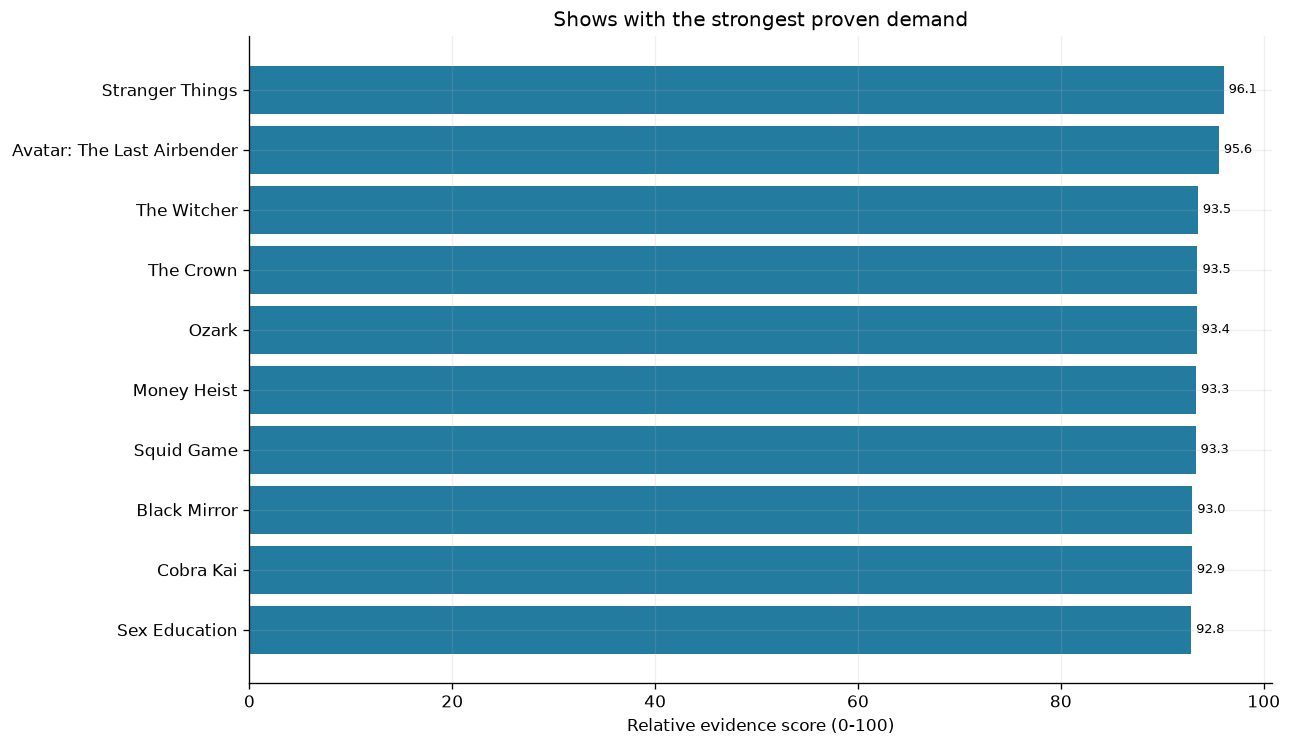

,show_title,rating,votes,total_hours,total_views,weeks_in_top10,proven_demand_score
0,Stranger Things,8.7,1149902,5844980000,369000000.0,34,96.052038
1,Avatar: The Last Airbender,9.3,309241,747100000,102500000.0,12,95.578205
2,The Witcher,8.2,481841,1250500000,83400000.0,18,93.506503
3,The Crown,8.7,199898,677260000,43900000.0,18,93.470259
4,Ozark,8.5,309552,751600000,NaN,13,93.390945
5,Money Heist,8.2,469640,1185400000,1500000.0,16,93.329734
6,Squid Game,8.0,435164,5048300000,396900000.0,42,93.278386
7,Black Mirror,8.8,535785,331600000,60100000.0,9,92.956025
8,Cobra Kai,8.5,177031,963960000,57900000.0,18,92.912405
9,Sex Education,8.4,273671,901760000,42200000.0,12,92.848407


In [8]:
# IMDb ratings are divided by ten so they use a zero-to-one scale.
candidates["rating_score"] = candidates["rating"].div(10).clip(0, 1)

# A logarithm reduces the effect of extremely large vote counts before percentile ranking.
candidates["vote_score"] = np.log1p(candidates["votes"]).rank(pct=True)

# Total viewing hours are used because this field is available across the full dataset history.
candidates["viewing_score"] = np.log1p(candidates["total_hours"]).rank(pct=True)

# Weeks in the Top 10 measure how long demand lasted relative to other shows.
candidates["longevity_score"] = candidates["weeks_in_top10"].rank(pct=True)

# The weighted score gives slightly more importance to quality and observed viewing.
candidates["proven_demand_score"] = 100 * (0.30 * candidates["rating_score"].fillna(0) + 0.25 * candidates["vote_score"].fillna(0) + 0.30 * candidates["viewing_score"].fillna(0) + 0.15 * candidates["longevity_score"].fillna(0))

# Sorting places the strongest evidence at the top of the review table.
candidates = candidates.sort_values("proven_demand_score", ascending=False).reset_index(drop=True)

# The first ten titles keep the shortlist chart focused on the main decision candidates.
strongest_demand = candidates.head(10).sort_values("proven_demand_score")

# A horizontal chart leaves enough space for long show titles.
fig, ax = plt.subplots(figsize=(11, 7))

# Each bar represents the relative proven-demand score.
bars = ax.barh(strongest_demand["show_title"], strongest_demand["proven_demand_score"], color=colours["blue"])

# The title and axis label state that this is a relative score, not a probability.
ax.set(title="Shows with the strongest proven demand", xlabel="Relative evidence score (0-100)")

# Score labels let the reader compare bars without estimating from the axis.
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=8)

# The finished figure is saved at report quality for the README.
fig.savefig(IMAGE_FOLDER / "proven_demand.png", dpi=300, bbox_inches="tight", facecolor="white")

# show displays the chart inside the notebook.
plt.show()

# This table shows the evidence behind the chart rather than only the final score.
display(candidates.head(10)[["show_title", "rating", "votes", "total_hours", "total_views", "weeks_in_top10", "proven_demand_score"]])

## 9. Questions 2 and 3 — Is interest growing, and is it reliable?

Momentum compares the recent four-week average with the trailing 12-month weekly average. Reliability requires at least four Top 10 weeks, 25,000 IMDb votes and a rating of at least 7. These are screening rules that can be adjusted, not universal industry thresholds.

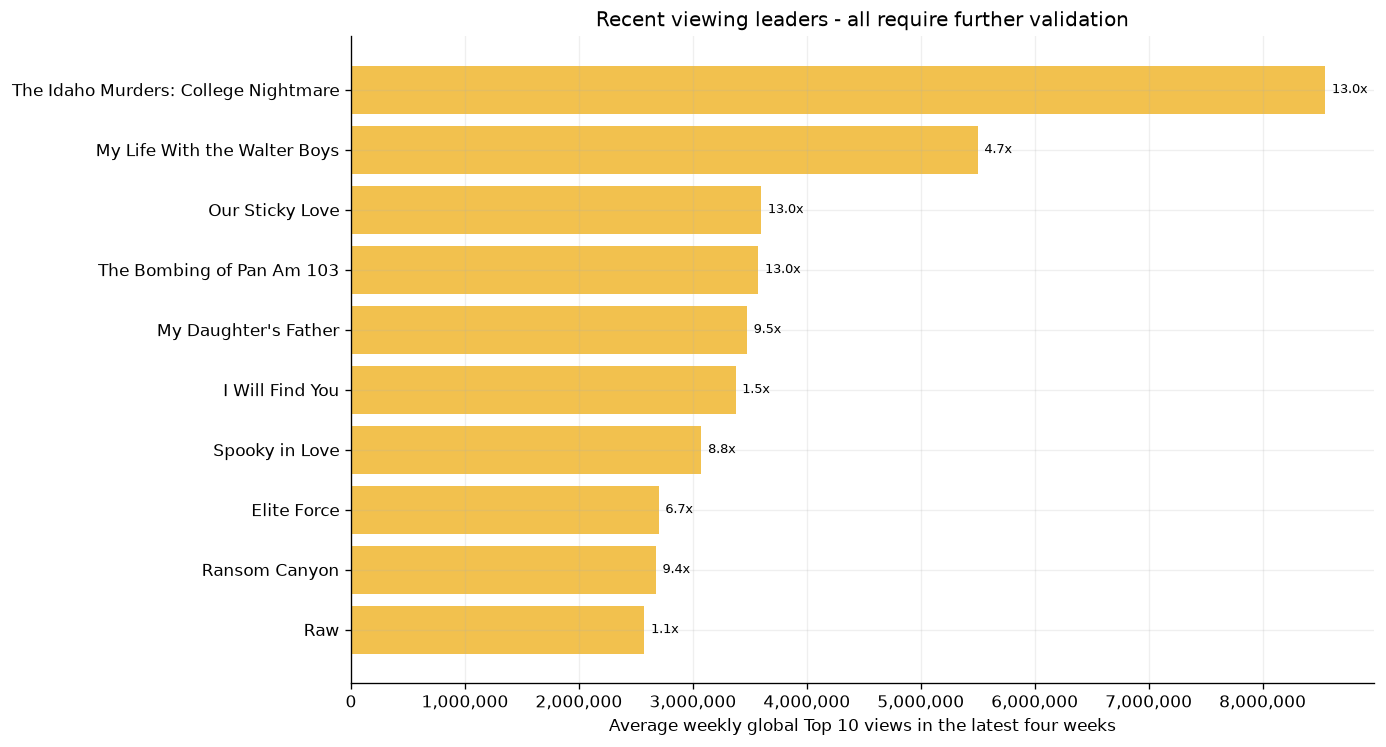

,show_title,average_weekly_views_12m,average_weekly_views_4w,momentum_ratio,weeks_in_top10,votes,reliable_demand,demand_pattern
0,Stranger Things,7.096154e+06,0.0,0.000000,34,1149902,True,More sustained evidence
1,Avatar: The Last Airbender,7.942308e+05,400000.0,0.503632,12,309241,True,More sustained evidence
2,The Witcher,3.538462e+05,0.0,0.000000,18,481841,True,More sustained evidence
3,The Crown,0.000000e+00,0.0,NaN,18,199898,True,More sustained evidence
4,Ozark,0.000000e+00,0.0,NaN,13,309552,True,More sustained evidence
5,Money Heist,0.000000e+00,0.0,NaN,16,469640,True,More sustained evidence
6,Squid Game,0.000000e+00,0.0,NaN,42,435164,True,More sustained evidence
7,Black Mirror,0.000000e+00,0.0,NaN,9,535785,True,More sustained evidence
8,Cobra Kai,0.000000e+00,0.0,NaN,18,177031,True,More sustained evidence
9,Sex Education,0.000000e+00,0.0,NaN,12,273671,True,More sustained evidence


In [9]:
# Sustained demand requires at least four separate Top 10 weeks.
candidates["sustained_demand"] = candidates["weeks_in_top10"].ge(4)

# A large vote base reduces reliance on a rating submitted by a small group.
candidates["large_vote_count"] = candidates["votes"].ge(25000)

# A rating of seven or more is used as the positive-quality screening threshold.
candidates["strong_rating"] = candidates["rating"].ge(7)

# All three conditions must be true for the lower-risk reliability flag.
candidates["reliable_demand"] = candidates["sustained_demand"] & candidates["large_vote_count"] & candidates["strong_rating"]

# A sharp increase with two or fewer Top 10 weeks is treated as possible temporary hype.
candidates["demand_pattern"] = np.select([candidates["weeks_in_top10"].le(2) & candidates["momentum_ratio"].gt(1.5), candidates["reliable_demand"]], ["Possible short-term spike", "More sustained evidence"], default="Mixed or limited evidence")

# The chart focuses on titles with actual viewing during the latest four weeks.
current_interest = candidates[candidates["average_weekly_views_4w"].gt(0)].sort_values("average_weekly_views_4w", ascending=False).head(10).sort_values("average_weekly_views_4w")

# A horizontal bar chart keeps the title names and recent-viewing values readable.
fig, ax = plt.subplots(figsize=(11, 7))

# Gold bars show that the current leaders still need more reliability evidence.
bars = ax.barh(current_interest["show_title"], current_interest["average_weekly_views_4w"], color=colours["gold"])

# The title states the decision supported by the visual.
ax.set(title="Recent viewing leaders - all require further validation", xlabel="Average weekly global Top 10 views in the latest four weeks")

# Comma formatting makes large weekly viewing numbers readable.
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# Each label adds the momentum ratio without forcing the reader to use a second axis.
ax.bar_label(bars, labels=[f"{value:.1f}x" for value in current_interest["momentum_ratio"]], padding=4, fontsize=8)

# The finished momentum chart is saved for GitHub.
fig.savefig(IMAGE_FOLDER / "current_momentum.png", dpi=300, bbox_inches="tight", facecolor="white")

# show displays the chart in the notebook output.
plt.show()

# This table answers the reliability question with the values behind each flag.
display(candidates.head(20)[["show_title", "average_weekly_views_12m", "average_weekly_views_4w", "momentum_ratio", "weeks_in_top10", "votes", "reliable_demand", "demand_pattern"]])

## 10. Question 4 — Which shows are realistically obtainable?

The available data cannot confirm present rights, platforms, production status or release timing. The model therefore places every show on hold for commercial checks instead of guessing availability.

In [10]:
# Available rights would pass the first commercial gate.
candidates["obtainability_result"] = np.where(candidates["rights_status"].eq("Available"), "Pass", "Hold - rights need checking")

# This view puts all obtainability evidence in one place for a researcher.
display(candidates.head(15)[["show_title", "rights_status", "current_platform", "production_status", "confirmed_release_date", "obtainability_result"]])

,show_title,rights_status,current_platform,production_status,confirmed_release_date,obtainability_result
0,Stranger Things,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
1,Avatar: The Last Airbender,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
2,The Witcher,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
3,The Crown,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
4,Ozark,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
5,Money Heist,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
6,Squid Game,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
7,Black Mirror,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
8,Cobra Kai,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking
9,Sex Education,Unconfirmed,Current UK platform unverified,Research required,NaT,Hold - rights need checking


## 11. Question 5 — How many Netflix UK viewers might each show attract?

No Netflix UK training data is available, so these are explicitly **illustrative planning estimates**, not predictions. The simple formula converts the relative score into a range that can later be recalibrated with real outcomes.

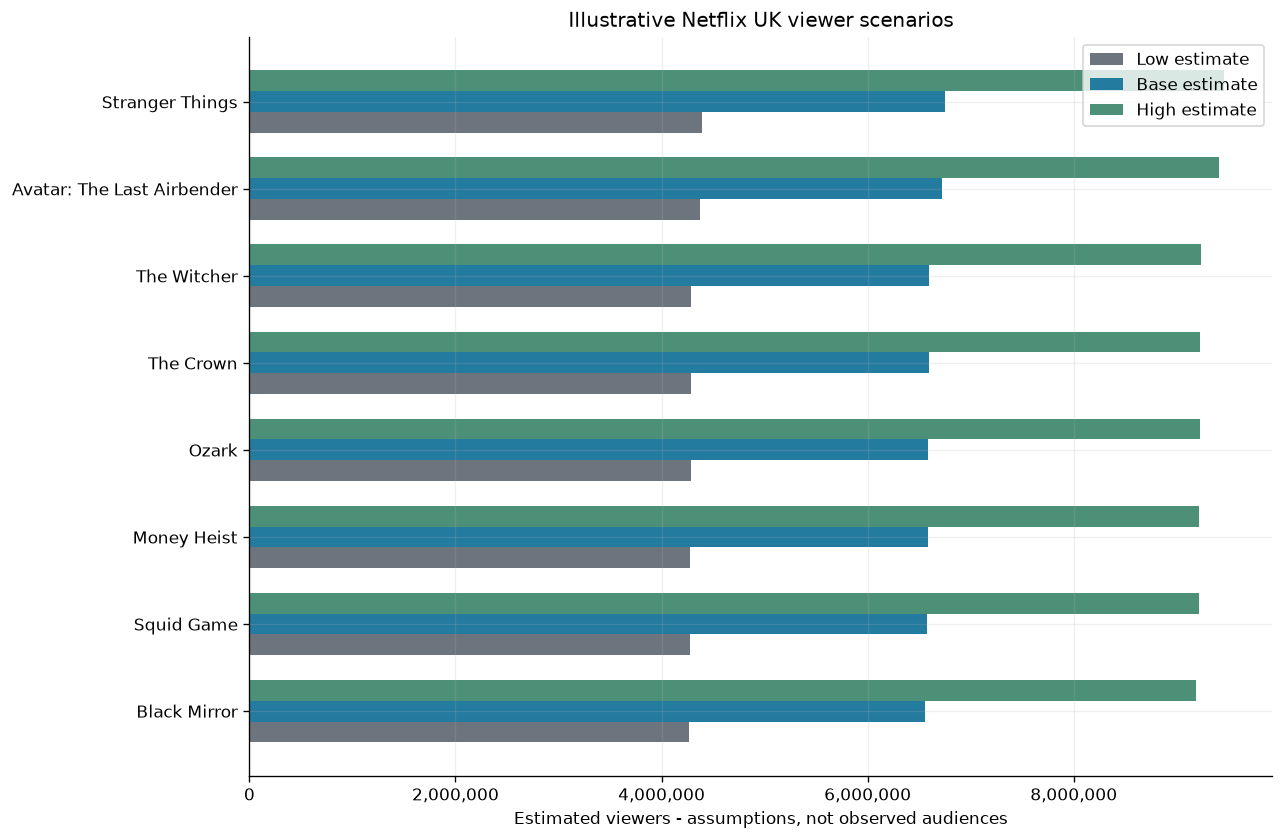

In [11]:
# This lower bound prevents the illustrative base case from starting at zero viewers.
minimum_base_viewers = 750000

# This range converts a full 100-point evidence score into an additional 6.25 million viewers.
score_based_viewers = 6250000

# The base case uses the proven-demand score as a transparent relative input.
candidates["estimated_viewers_base"] = minimum_base_viewers + score_based_viewers * candidates["proven_demand_score"] / 100

# The Low case reduces the Base estimate by 35 percent.
candidates["estimated_viewers_low"] = candidates["estimated_viewers_base"] * 0.65

# The High case increases the Base estimate by 40 percent.
candidates["estimated_viewers_high"] = candidates["estimated_viewers_base"] * 1.40

# melt converts the three scenario columns into a chart-friendly long table.
viewer_scenarios = candidates.head(8).melt(id_vars="show_title", value_vars=["estimated_viewers_low", "estimated_viewers_base", "estimated_viewers_high"], var_name="scenario", value_name="estimated_viewers")

# Short display labels make the chart legend easier to read.
viewer_scenarios["scenario"] = viewer_scenarios["scenario"].map({"estimated_viewers_low": "Low estimate", "estimated_viewers_base": "Base estimate", "estimated_viewers_high": "High estimate"})

# pivot places each scenario beside the others for grouped horizontal bars.
scenario_chart = viewer_scenarios.pivot(index="show_title", columns="scenario", values="estimated_viewers").sort_values("Base estimate")

# subplots creates one figure and one axis for the grouped scenario chart.
fig, ax = plt.subplots(figsize=(11, 8))

# These positions keep the three scenario bars aligned for each title.
positions = np.arange(len(scenario_chart))

# The Low bars show the cautious outcome.
ax.barh(positions - 0.24, scenario_chart["Low estimate"], height=0.24, color=colours["grey"], label="Low estimate")

# The Base bars show the central assumption.
ax.barh(positions, scenario_chart["Base estimate"], height=0.24, color=colours["blue"], label="Base estimate")

# The High bars show the optimistic outcome.
ax.barh(positions + 0.24, scenario_chart["High estimate"], height=0.24, color=colours["green"], label="High estimate")

# The title names are attached to the shared bar positions.
ax.set_yticks(positions, scenario_chart.index)

# The title clearly states that the values are illustrative estimates.
ax.set(title="Illustrative Netflix UK viewer scenarios", xlabel="Estimated viewers - assumptions, not observed audiences")

# Comma formatting makes the viewer scale easier to read.
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

# The legend distinguishes the Low, Base and High cases.
ax.legend()

# The finished scenario chart is saved for the README.
fig.savefig(IMAGE_FOLDER / "viewer_scenarios.png", dpi=300, bbox_inches="tight", facecolor="white")

# show displays the scenario chart in the notebook.
plt.show()

## 12. Questions 6 and 7 — Would value justify cost, and how sensitive is the result?

The assumed value per viewer is visible and easy to replace. Benefit-cost ratio, ROI and break-even viewers remain blank until a real licence cost is entered. The recommendation cannot pass the final commercial gate while rights and cost are unknown.

In [12]:
# This illustrative value converts viewers into a consistent comparison measure.
value_per_viewer_gbp = 2.50

# The projected Base value multiplies the Base audience estimate by the stated assumption.
candidates["projected_value_base_gbp"] = candidates["estimated_viewers_base"] * value_per_viewer_gbp

# The benefit-cost ratio stays missing while licence cost is unknown.
candidates["benefit_cost_ratio"] = candidates["projected_value_base_gbp"] / candidates["licence_cost_gbp"]

# ROI also stays missing rather than treating an unknown licence as free.
candidates["projected_roi"] = (candidates["projected_value_base_gbp"] - candidates["licence_cost_gbp"]) / candidates["licence_cost_gbp"]

# Break-even viewers show the audience needed to recover a known licence cost.
candidates["break_even_viewers"] = candidates["licence_cost_gbp"] / value_per_viewer_gbp

# Low-case value is calculated separately for sensitivity testing.
candidates["projected_value_low_gbp"] = candidates["estimated_viewers_low"] * value_per_viewer_gbp

# High-case value is calculated separately for sensitivity testing.
candidates["projected_value_high_gbp"] = candidates["estimated_viewers_high"] * value_per_viewer_gbp

# This flag becomes usable after a licence cost is entered.
candidates["passes_low_scenario"] = candidates["projected_value_low_gbp"].ge(candidates["licence_cost_gbp"])

# This flag identifies titles that would work only with optimistic viewing assumptions.
candidates["optimistic_case_only"] = candidates["projected_value_low_gbp"].lt(candidates["licence_cost_gbp"]) & candidates["projected_value_high_gbp"].ge(candidates["licence_cost_gbp"])

# The evidence shortlist uses the top twenty percent of proven-demand scores.
shortlist_cutoff = candidates["proven_demand_score"].quantile(0.80)

# Strong evidence can create a research shortlist, but unknown rights and costs prevent approval.
candidates["recommendation"] = np.where(candidates["proven_demand_score"].ge(shortlist_cutoff), "Shortlist for rights and cost research", "Watchlist")

# This table brings demand, scenarios, commercial gaps and the recommendation together.
display(candidates.head(20)[["show_title", "proven_demand_score", "estimated_viewers_low", "estimated_viewers_base", "estimated_viewers_high", "licence_cost_gbp", "benefit_cost_ratio", "projected_roi", "break_even_viewers", "recommendation"]])

,show_title,proven_demand_score,estimated_viewers_low,estimated_viewers_base,estimated_viewers_high,licence_cost_gbp,benefit_cost_ratio,projected_roi,break_even_viewers,recommendation
0,Stranger Things,96.052038,4389614.035507,6753252.362319,9454553.307246,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
1,Avatar: The Last Airbender,95.578205,4370364.590873,6723637.832113,9413092.964958,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
2,The Witcher,93.506503,4286201.683054,6594156.435467,9231819.009654,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
3,The Crown,93.470259,4284729.268171,6591891.181802,9228647.654523,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
4,Ozark,93.390945,4281507.129626,6586934.045578,9221707.663809,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
5,Money Heist,93.329734,4279020.451991,6583108.387678,9216351.742749,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
6,Squid Game,93.278386,4276934.418034,6579899.104668,9211858.746536,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
7,Black Mirror,92.956025,4263838.524301,6559751.575848,9183652.206187,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
8,Cobra Kai,92.912405,4262066.469579,6557025.337814,9179835.472939,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research
9,Sex Education,92.848407,4259466.537427,6553025.442195,9174235.619073,NaN,<NA>,<NA>,NaN,Shortlist for rights and cost research


## 13. What information is still missing?

The missing-data register separates what this analysis can show from what a real acquisition team would still need.

In [13]:
# Each row records one missing input, where it should come from and why it matters.
data_gaps = pd.DataFrame([
    ["Original UK audience", "BARB or broadcaster reports", "Confirms previous-season UK demand"],
    ["Google Trends history", "Downloaded Google Trends data", "Measures current UK search interest"],
    ["Netflix UK title audience", "Internal Netflix analytics", "Calibrates the viewer estimates"],
    ["Licence cost", "Distributor quotation", "Required for ROI and break-even"],
    ["Rights availability", "Distributor or legal team", "Determines whether the title is obtainable"],
    ["Current platform", "Current rights research", "Identifies exclusivity conflicts"],
    ["Production status", "Studio or reliable trade source", "Shows whether more episodes are realistic"],
    ["Confirmed release date", "Studio or broadcaster", "Supports launch timing"],
], columns=["missing_information", "preferred_source", "reason_needed"])

# display makes the research requirements visible at the end of the analysis.
display(data_gaps)

,missing_information,preferred_source,reason_needed
0,Original UK audience,BARB or broadcaster reports,Confirms previous-season UK demand
1,Google Trends history,Downloaded Google Trends data,Measures current UK search interest
2,Netflix UK title audience,Internal Netflix analytics,Calibrates the viewer estimates
3,Licence cost,Distributor quotation,Required for ROI and break-even
4,Rights availability,Distributor or legal team,Determines whether the title is obtainable
5,Current platform,Current rights research,Identifies exclusivity conflicts
6,Production status,Studio or reliable trade source,Shows whether more episodes are realistic
7,Confirmed release date,Studio or broadcaster,Supports launch timing


## 14. Export the results

The full decision table supports further analysis, while the smaller research template gives a clear place to enter verified commercial information later.

In [14]:
# These columns contain the main evidence, assumptions, gaps and recommendation.
decision_columns = ["show_title", "rating", "votes", "total_hours", "total_views", "weeks_in_top10", "average_weekly_views_12m", "average_weekly_views_4w", "momentum_ratio", "proven_demand_score", "reliable_demand", "demand_pattern", "metadata_match_note", "original_uk_audience", "google_trends_average_12m", "google_trends_average_4w", "rights_status", "current_platform", "production_status", "confirmed_release_date", "estimated_viewers_low", "estimated_viewers_base", "estimated_viewers_high", "projected_value_base_gbp", "licence_cost_gbp", "benefit_cost_ratio", "projected_roi", "break_even_viewers", "recommendation"]

# The complete table is exported without the pandas index because the row number has no business meaning.
candidates[decision_columns].to_csv(OUTPUT_FOLDER / "acquisition_decision_table.csv", index=False)

# The research template contains the top titles and only the fields that still need verification.
candidates.head(20)[["show_title", "original_uk_audience", "google_trends_average_12m", "google_trends_average_4w", "rights_status", "current_platform", "production_status", "confirmed_release_date", "licence_cost_gbp", "netflix_uk_title_audience"]].to_csv(OUTPUT_FOLDER / "shortlist_research_template.csv", index=False)

# The data-gap register is exported so it can be tracked outside the notebook.
data_gaps.to_csv(OUTPUT_FOLDER / "data_gap_register.csv", index=False)

# This message confirms that the main output files were created.
print("Analysis complete. Tables were saved in outputs/ and charts were saved in images/.")

Analysis complete. Tables were saved in outputs/ and charts were saved in images/.


## Conclusion

This project creates a defensible research shortlist from the evidence available. It does not claim to prove UK acquisition viability because current rights, UK viewing, Google Trends and costs are not included in the source data. Those limits are part of the conclusion, not hidden from the reader.

Stranger Things leads the evidence score. Squid Game has 396.9 million reported views and 42 Top 10 weeks, but ranks lower when IMDb evidence and comparable viewing hours are included. Based on this analysis, Netflix could make four practical decisions:

1. **Prioritise commercial checks for the strongest titles.** Stranger Things, Avatar: The Last Airbender, The Witcher, The Crown and Ozark should move first into rights, cost and UK-audience research because they have the strongest combined evidence.
2. **Separate established demand from recent spikes.** Titles with high recent viewing but limited history should be monitored or supported with targeted marketing tests rather than treated as proven long-term demand.
3. **Use viewer scenarios for planning, not approval.** The Low, Base and High cases can help compare possible exposure, but no deal should be approved until the assumptions are calibrated with Netflix UK title-level audiences.
4. **Apply a commercial stop/go gate.** A title should proceed only after rights are confirmed and its known cost passes the Low or Base benefit-cost test. Titles that work only in the High case should be treated as higher risk.

My next step would be to collect UK-specific audience and Google Trends information for the shortlist, then replace the illustrative value assumptions with verified licence costs and performance data.